Saving Final_Cleaned_Voyage_Data - Copy - Copy.csv to Final_Cleaned_Voyage_Data - Copy - Copy.csv
    DepartureTime     ArrivalTime       LATd       LONd       LATa       LONa  \
0  03-11-17 10:34   17-11-17 4:32  54.160428  12.138012  54.366522  10.139380   
1  25-11-17 18:48  26-11-17 19:39  54.160100  12.117752  57.404085  21.530300   
2  27-11-17 13:42  22-12-17 14:33  57.406483  21.534433  57.680388  10.672802   
3  03-06-18 12:49   08-06-18 5:32  57.596360  11.691197  54.160170  12.141002   
4   24-08-18 8:06  14-09-18 18:41  54.368100  10.127703  59.422140  27.728842   

   Voyage_Distance_Km  AvgSpeedkmph  Std_SpeedKMpH  Avg_Course  draft_km  \
0          914.354259     11.080691       3.011309  205.902439      8.18   
1          719.275934     15.388585       2.325094   70.620690      8.18   
2         1351.906130     13.531040       2.515725  228.292881      8.18   
3          621.049441      8.277641       4.927827  187.935849      8.18   
4         2187.640319     15.280086

<ipython-input-1-18593e772d6f>:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col])
<ipython-input-1-18593e772d6f>:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col])


                    DepartureTime  ArrivalTime      LATd      LONd      LATa  \
DepartureTime            1.000000     0.857857  0.022732  0.037897  0.012064   
ArrivalTime              0.857857     1.000000  0.022336  0.037098  0.009547   
LATd                     0.022732     0.022336  1.000000  0.639484 -0.205627   
LONd                     0.037897     0.037098  0.639484  1.000000 -0.228563   
LATa                     0.012064     0.009547 -0.205627 -0.228563  1.000000   
LONa                    -0.009717    -0.010056 -0.253527 -0.354212  0.651127   
Voyage_Distance_Km      -0.010093     0.018105  0.238463  0.166171  0.169201   
AvgSpeedkmph             0.019893     0.006144 -0.076569 -0.043157 -0.014873   
Std_SpeedKMpH           -0.023040    -0.027978 -0.114770 -0.075721 -0.079513   
Avg_Course               0.021615     0.021825  0.462096  0.705035 -0.523686   
draft_km                -0.017096    -0.021458  0.083365  0.088313  0.076756   
breadthKM                0.003477    -0.

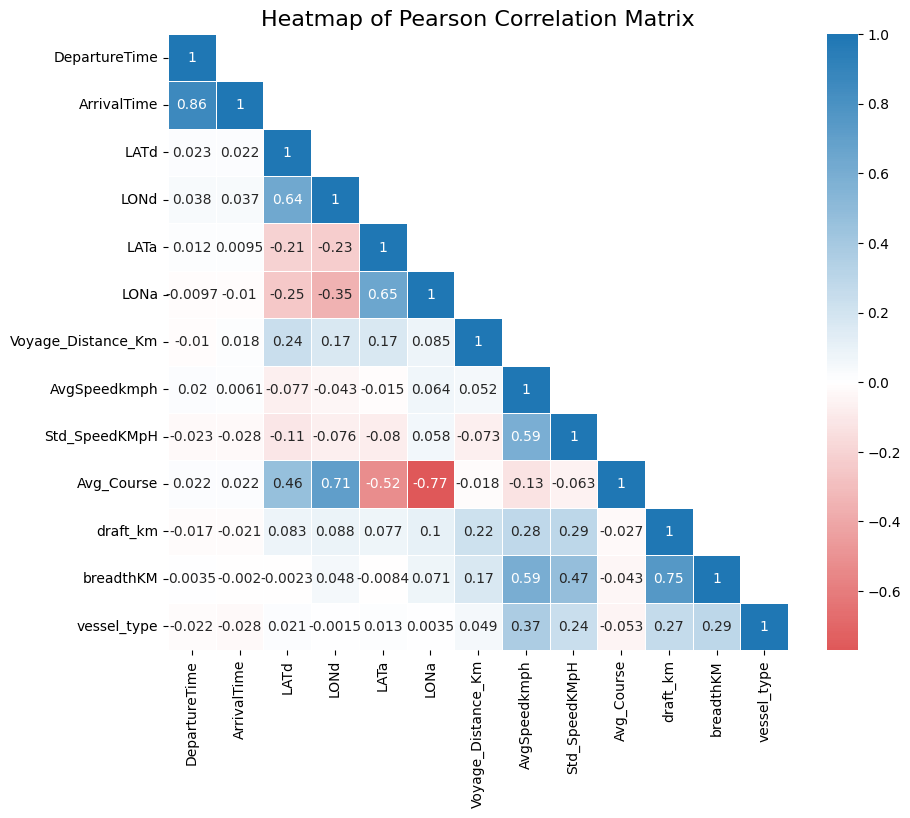

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from google.colab import files

# Step 1: Upload the File
uploaded = files.upload()

# Step 2: Read the File into a DataFrame
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Display the first few rows of the DataFrame
print(df.head())

# Step 3: Convert date and time columns to numeric format
# Identify date/time columns
date_columns = df.select_dtypes(include=['datetime64', 'datetime64[ns]', 'object']).columns

# Convert date/time columns to Unix timestamp
for col in date_columns:
    try:
        df[col] = pd.to_datetime(df[col])
        df[col] = df[col].apply(lambda x: x.timestamp())
    except ValueError:
        # If conversion fails, skip the column
        continue

# Calculate the Pearson Correlation Matrix
correlation_matrix = df.corr(method='pearson')

# Print the correlation matrix
print(correlation_matrix)

# Step 4: Create a Heatmap to Visualize the Correlation Matrix

# Define the size of the figure
plt.figure(figsize=(10, 8))

# Generate a mask for the upper triangle excluding the diagonal
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
np.fill_diagonal(mask, False)

# Custom colors for the heatmap
positive_color = '#1f77b4'  # Deep, vibrant blue
zero_color = '#ffffff'      # White
negative_color = '#d62728'  # Rich, bright red

# Create a custom colormap
cmap = LinearSegmentedColormap.from_list('Custom', [negative_color, zero_color, positive_color])

# Create the heatmap using Seaborn
sns.heatmap(correlation_matrix, annot=True, cmap=cmap, center=0, linewidths=0.5, mask=mask)

# Add title
plt.title('Heatmap of Pearson Correlation Matrix', fontsize=16)

# Display the plot
plt.show()
